In [65]:
import os
import pickle
import pathlib

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import pandas as pd

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice


plt.rcParams['pdf.fonttype']=42
%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig5_novel_activity_rate')
figdir.mkdir(exist_ok=True, parents=True)

In [146]:
block_rate = stx.novel_activity_rate.BlockTransitionActivityRate(ts_key='F_dff')

4467331.1
4467331.2
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
4467332.1
4467332.2
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
4467333.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


mCherry6
mCherry7
mCherry8
mCherry9
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.2


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.3


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.4
4467975.5
Cre7
Cre9


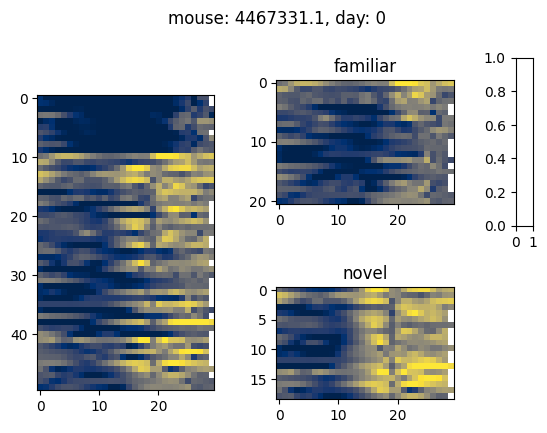

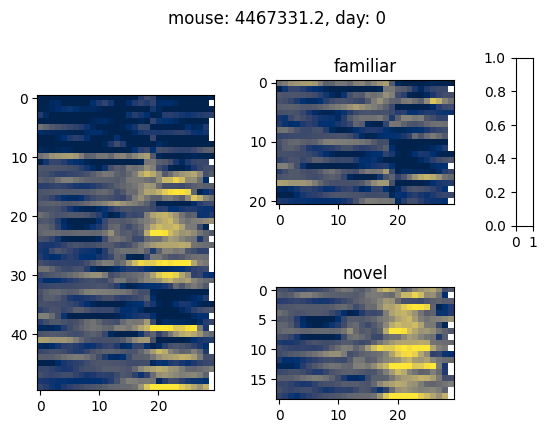

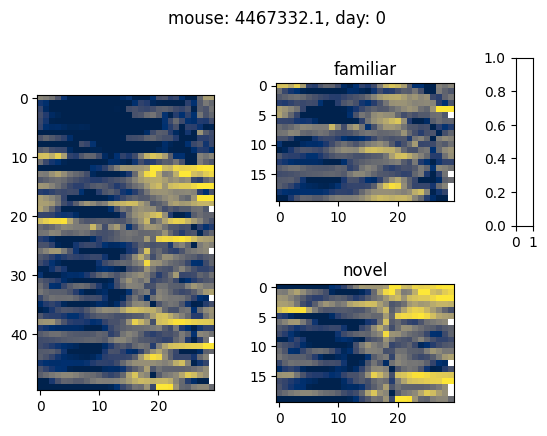

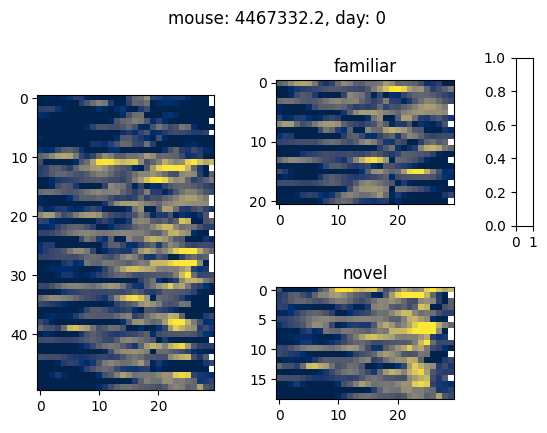

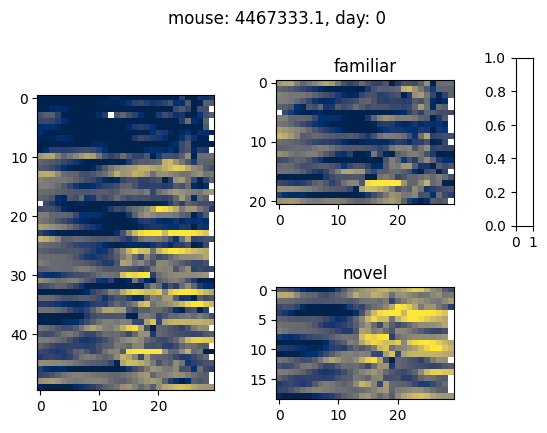

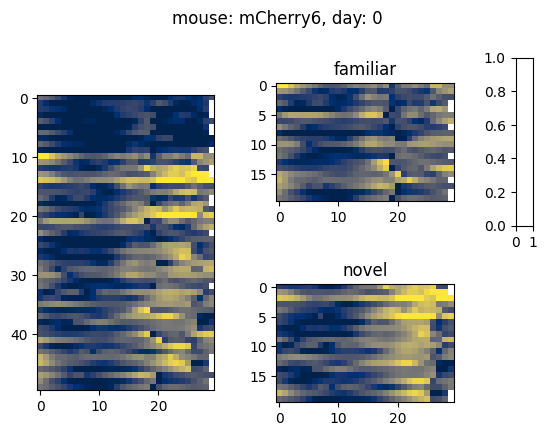

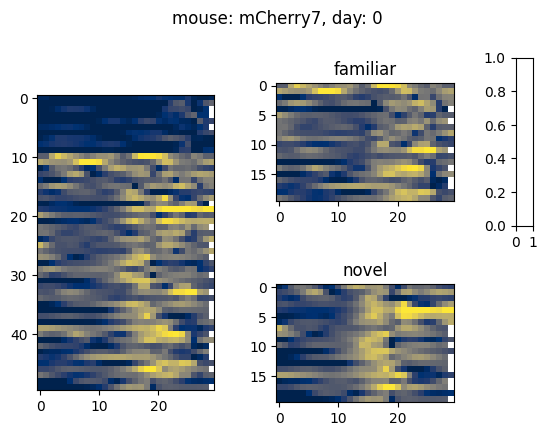

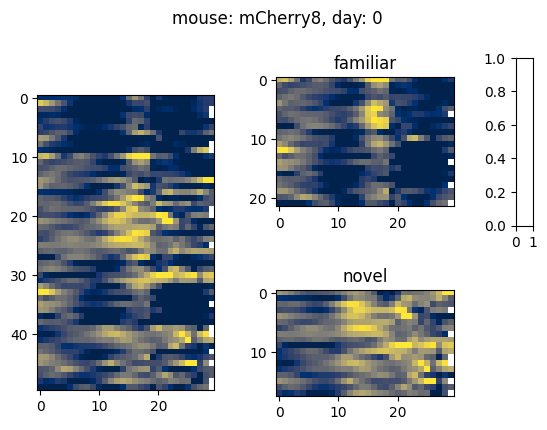

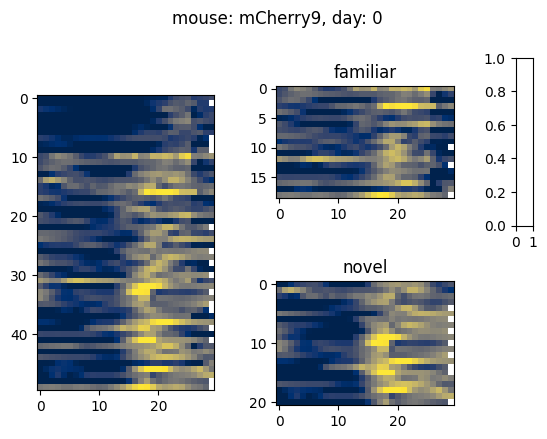

In [149]:
for mouse in ctrl_mice:
    block_rate.plot_single_session('ctrl', mouse, 0, log=False, baseline_corr=True, cmap='cividis', vmin=1)

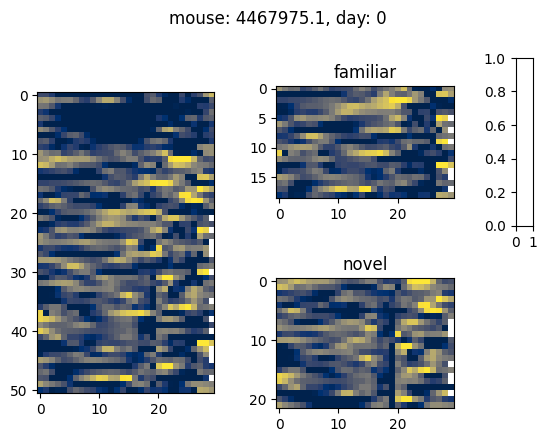

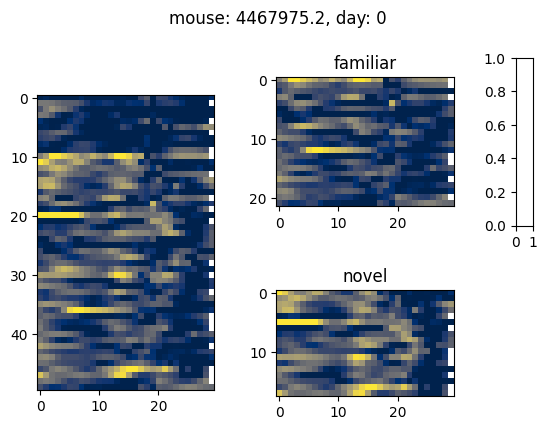

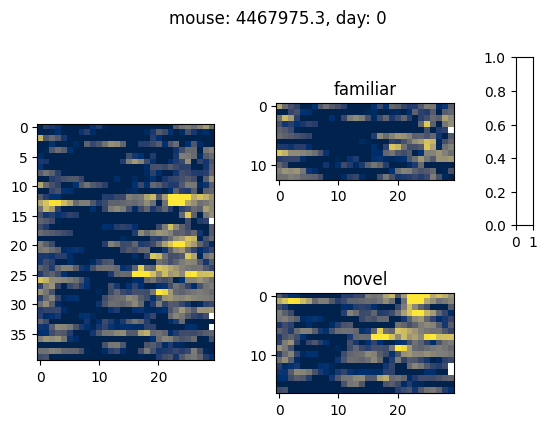

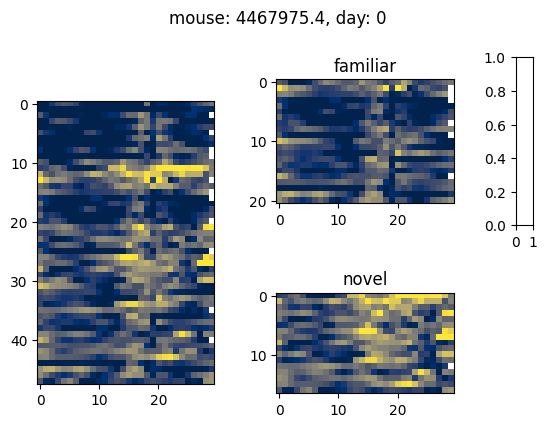

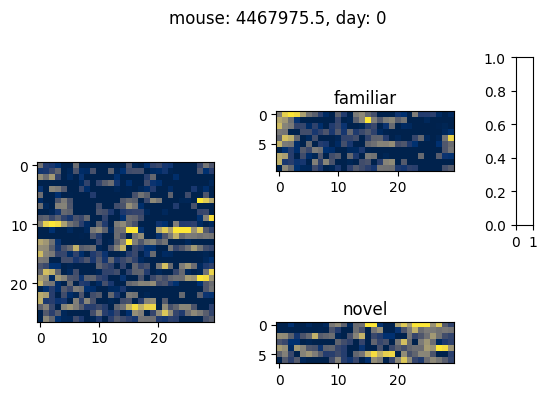

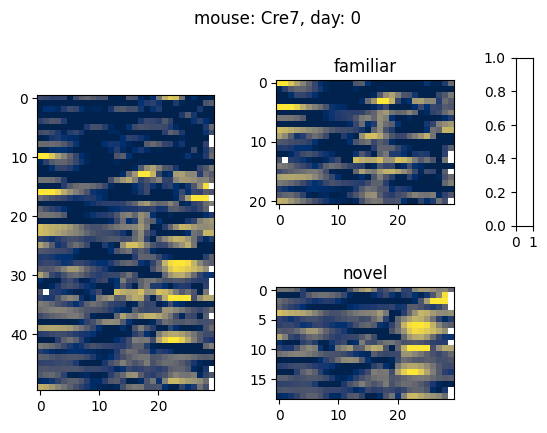

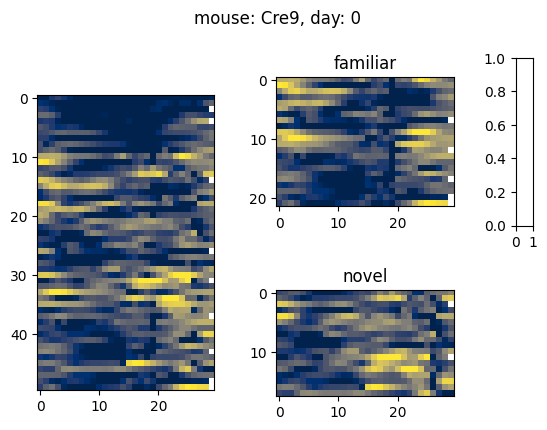

In [150]:
for mouse in ko_mice:
    block_rate.plot_single_session('ko', mouse, 0, log=False, baseline_corr=True, cmap='cividis', vmin=1)

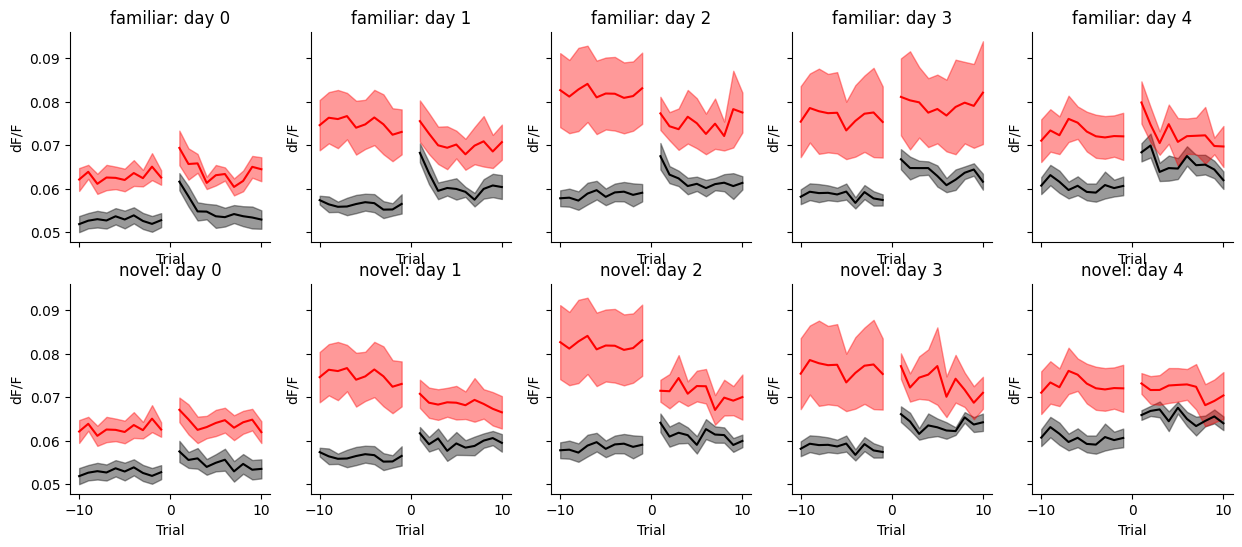

In [151]:
# plot average fluorescence with no normalization
fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


for day in np.arange(5):
    base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    fam = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    nov = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}

    for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
        for i, mouse in enumerate(mice):
            data = block_rate.activity_rates[cond][mouse][day]
            
            _base = np.nanmean(np.nanmean(data['baseline_act'],axis=1),axis=-1)
            # if _base.shape[0]<10:
            base[cond][i,:_base.shape[0]] = _base

            _fam = np.nanmean(np.nanmean(data['block_fam_act'],axis=1),axis=-1)[:10]
            fam[cond][i,:_fam.shape[0]] = _fam
        
            _nov = np.nanmean(np.nanmean(data['block_nov_act'],axis=1), axis=-1)[:10]
            nov[cond][i,:_nov.shape[0]] = _nov

    for cond, color in zip(('ctrl','ko'), ('black', 'red')):
        x_base = np.arange(-10,0)
        mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_base, mu, color=color)
        ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        ax[1,day].plot(x_base, mu, color=color)
        ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        x_block = np.arange(1,11)
        mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_block, mu, color=color)
        ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
        ax[1,day].plot(x_block, mu, color=color)
        ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        ax[0,day].set_title(f'familiar: day {day}')
        ax[1,day].set_title(f'novel: day {day}')

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_ylabel('dF/F')
    a.set_xlabel('Trial')


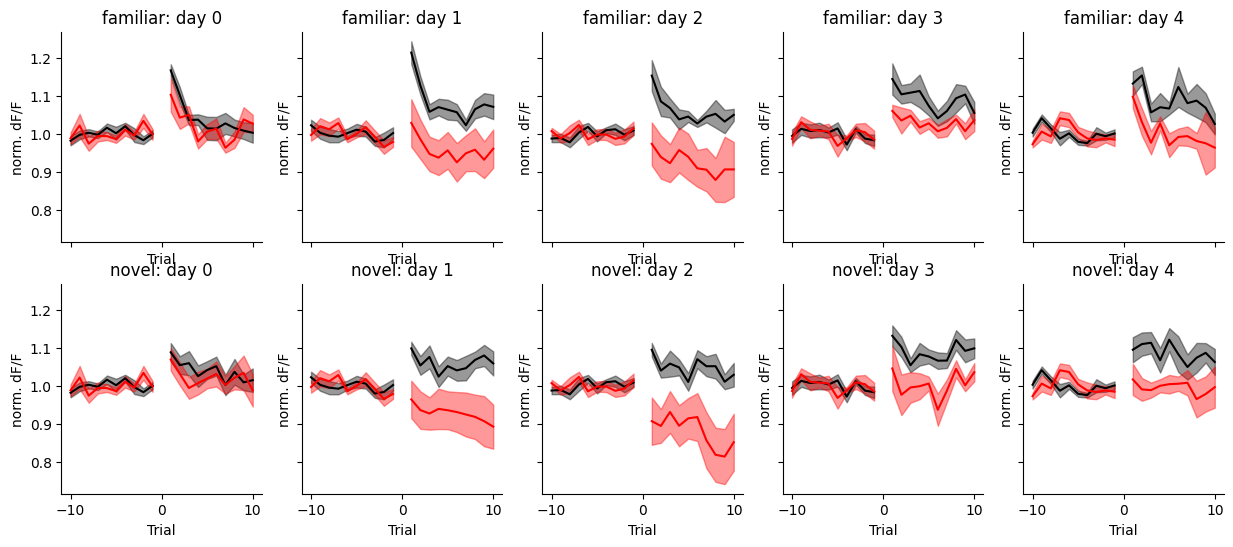

In [152]:
# plot average fluorescence, normalizing to baseline population activity
fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


for day in np.arange(5):
    base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    fam = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    nov = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}

    for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
        for i, mouse in enumerate(mice):
            data = block_rate.activity_rates[cond][mouse][day]
            
            _base = np.nanmean(np.nanmean(data['baseline_act'],axis=1),axis=-1)
            # if _base.shape[0]<10:
            base[cond][i,:_base.shape[0]] = _base/_base.mean()

            _fam = np.nanmean(np.nanmean(data['block_fam_act'],axis=1),axis=-1)[:10]/_base.mean()
            fam[cond][i,:_fam.shape[0]] = _fam
        
            _nov = np.nanmean(np.nanmean(data['block_nov_act'],axis=1), axis=-1)[:10]/_base.mean()
            nov[cond][i,:_nov.shape[0]] = _nov

    for cond, color in zip(('ctrl','ko'), ('black', 'red')):
        x_base = np.arange(-10,0)
        mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_base, mu, color=color)
        ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        ax[1,day].plot(x_base, mu, color=color)
        ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        x_block = np.arange(1,11)
        mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_block, mu, color=color)
        ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
        ax[1,day].plot(x_block, mu, color=color)
        ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        ax[0,day].set_title(f'familiar: day {day}')
        ax[1,day].set_title(f'novel: day {day}')

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_ylabel('norm. dF/F')
    a.set_xlabel('Trial')

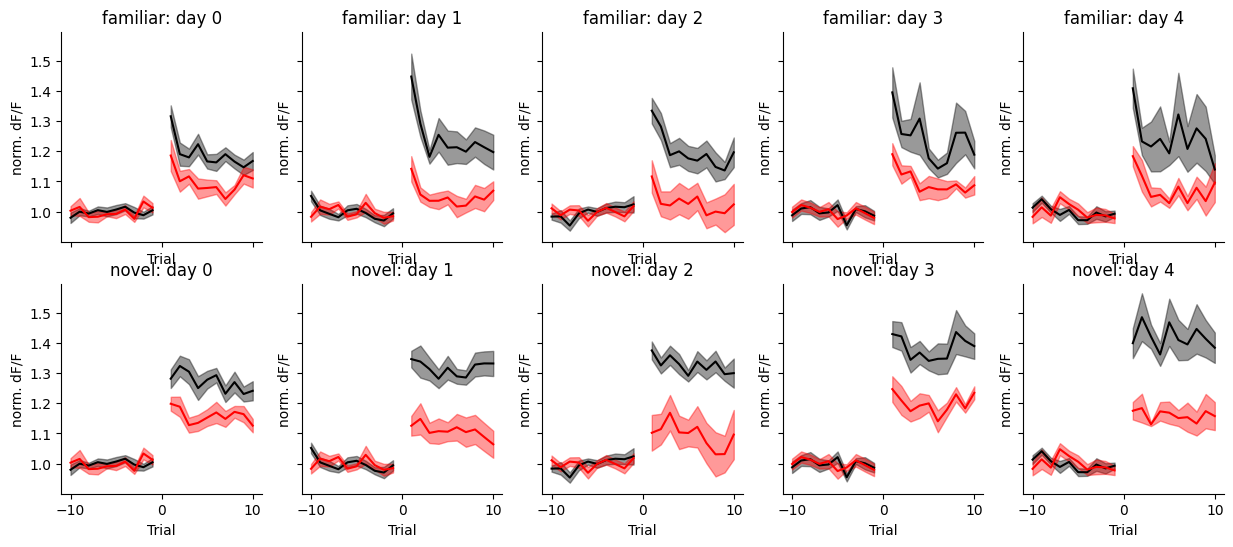

In [153]:
# plot average fluoresence, normalizing each cell to its baseline population activity
fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


for day in np.arange(5):
    base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    fam = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
    nov = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}

    for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
        for i, mouse in enumerate(mice):
            data = block_rate.activity_rates[cond][mouse][day]
            
            cell_denom = data['baseline_avg_act']
            _base = np.nanmean(np.nanmean(data['baseline_act']/cell_denom,axis=1),axis=-1)
           
            # if _base.shape[0]<10:
            base[cond][i,:_base.shape[0]] = _base

            _fam = np.nanmean(np.nanmean(data['block_fam_act']/cell_denom,axis=1),axis=-1)[:10]
            fam[cond][i,:_fam.shape[0]] = _fam
        
            _nov = np.nanmean(np.nanmean(data['block_nov_act']/cell_denom,axis=1), axis=-1)[:10]
            nov[cond][i,:_nov.shape[0]] = _nov

    for cond, color in zip(('ctrl','ko'), ('black', 'red')):
        x_base = np.arange(-10,0)
        mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_base, mu, color=color)
        ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        ax[1,day].plot(x_base, mu, color=color)
        ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

        x_block = np.arange(1,11)
        mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
        ax[0,day].plot(x_block, mu, color=color)
        ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
        ax[1,day].plot(x_block, mu, color=color)
        ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

        ax[0,day].set_title(f'familiar: day {day}')
        ax[1,day].set_title(f'novel: day {day}')

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_ylabel('norm. dF/F')
    a.set_xlabel('Trial')

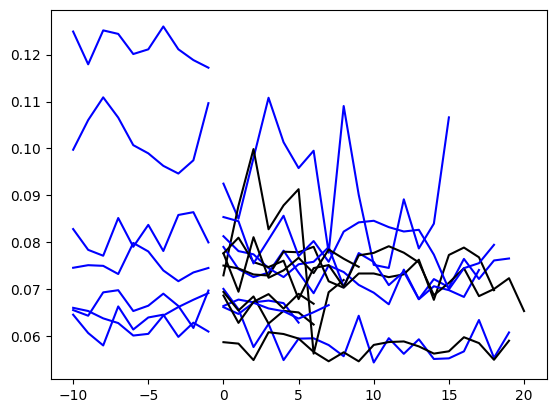

In [154]:
cond, day = 'ko',  2

fig, ax = plt.subplots()
for mouse in ko_mice:
    data = block_rate.activity_rates[cond][mouse][day]




    x_base = np.arange(-10,0)


    y_base = np.nanmean(np.nanmean(data['baseline_act'],axis=1),axis=-1)
    y_fam = np.nanmean(np.nanmean(data['block_fam_act'],axis=1),axis=-1) 
    x_fam = np.arange(0, y_fam.shape[0])
    y_nov = np.nanmean(np.nanmean(data['block_nov_act'],axis=1),axis=-1)
    x_nov = np.arange(0, y_nov.shape[0])

    ax.plot(x_base,y_base, color='blue')
    ax.plot(x_fam, y_fam, color='blue')
    ax.plot(x_nov, y_nov, color='black')